In [91]:
import numpy as np
import matplotlib.pyplot as plt
from Librerie import operazioni as op
import numpy as np
import matplotlib.pyplot as plt
from math import floor, ceil
from iminuit import Minuit
from scipy.stats import expon, norm
from iminuit.cost import ExtendedBinnedNLL
from IPython.display import display
from Librerie import funzioni as func
from scipy.stats import gamma, norm
from math import ceil, floor
from datetime import date

In [64]:
days_passed = [31,38,34,38,28,39,42,14,24,31,29,29,36,33,34,31,27,39,25,36,30,34]
pain_values = [7, 8, 6, 0, 0, 0,10, 8, 9,10, 7, 8, 9, 5, 8, 0, 9, 9, 7, 0,10, 9, 8,9]

print (len(days_passed))
print (len(pain_values))

22
24


In [65]:
def istogramma(dati, name):
    N_punti = len(dati)
    n_bins = int(np.sqrt(N_punti))                                                      
    n_bins1 = op.sturges(len(dati))
    n_bins2 = 20                                               
    x_range = (np.min(dati), np.max(dati))                                               
    
    fig, ax = plt.subplots(figsize=(8, 5))
    
    conteggi, bordi, patches = ax.hist(dati, 
                                       bins=n_bins2, 
                                       range=x_range, 
                                       color='skyblue', 
                                       edgecolor='black', 
                                       alpha=0.7, 
                                       label=f'Dati ($N$={N_punti})',
                                       density = True) 

    # 3. Formattazione
    ax.set_title(name)
    ax.set_xlabel('Valore')
    ax.set_ylabel('Densità di probabilità') 
    ax.legend()
    ax.grid(axis='y', alpha=0.3)                                                           
    ax.grid(axis='x', alpha=0.3)                                                           
    plt.show()
    return conteggi, bordi


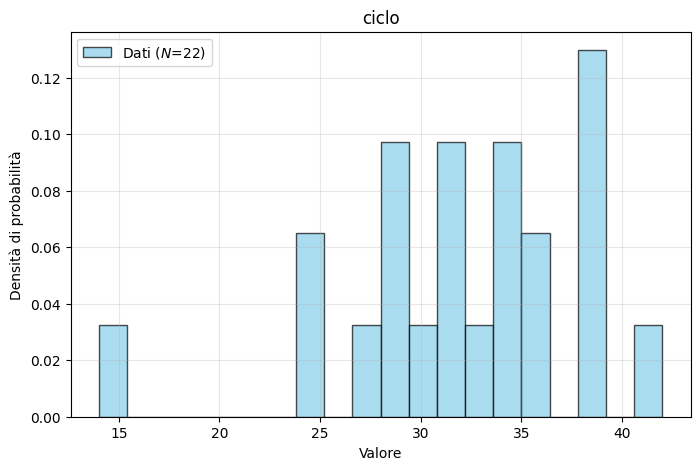

(array([0.03246753, 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.06493506, 0.        , 0.03246753,
        0.0974026 , 0.03246753, 0.0974026 , 0.03246753, 0.0974026 ,
        0.06493506, 0.        , 0.12987013, 0.        , 0.03246753]),
 array([14. , 15.4, 16.8, 18.2, 19.6, 21. , 22.4, 23.8, 25.2, 26.6, 28. ,
        29.4, 30.8, 32.2, 33.6, 35. , 36.4, 37.8, 39.2, 40.6, 42. ]))

In [66]:
name = 'ciclo'
istogramma(days_passed, name )

True
N_signal = 24.583 +/- 6.015
mu = 33.266 +/- 2.218
sigma = 6.871 +/- 1.811


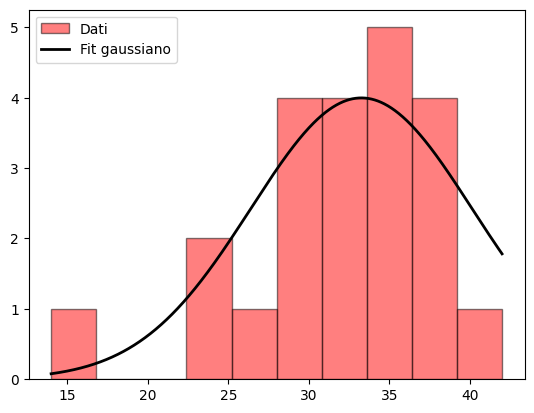

In [67]:
#definisco le variabili da dare a iminuit per iniziare il fit
M = ceil (max (days_passed))
m = floor (min (days_passed))
MU = op.media ( days_passed)
DEV = op.deviazione_standard (days_passed)
   
# creo un istogramma numpy per inizializzare bin_content e bin_edges    
N_bins = 10
x_range = (m, M)
x_val = np.linspace(m, M, 1000)
bin_content, bin_edges = np.histogram (days_passed, bins = N_bins, range = x_range)
N_events = sum(bin_content)
   
#inizializzo la cost_function per il fit e lo eseguo BINNED
cost_func = ExtendedBinnedNLL (bin_content, bin_edges, func.gauss_binned)
my_minuit = Minuit (cost_func,N_signal = N_events, mu = MU, sigma = DEV) 
my_minuit.migrad (ncall = 10000)
      
#stampo i valori ottenuti dal fit BINNED
print (my_minuit.valid)

# formatted output
for par, val, err in zip (my_minuit.parameters, my_minuit.values, my_minuit.errors) :
    print(f'{par} = {val:.3f} +/- {err:.3f}') 


   
#estraggo i valori ottenuti dal fit BINNED
N_signal_fit = my_minuit.values[0]
mu_fit       = my_minuit.values[1]
sigma_fit    = my_minuit.values[2]

   
# 1. Crea l'asse X con 1000 punti continui che coprono ESATTAMENTE l'estensione dell'istogramma
x_val = np.linspace(m, M, 1000)

# 2. Per il GRAFICO, usa la PDF (la forma a campana), scalandola per l'istogramma
from scipy.stats import norm
bin_width = bin_edges[1] - bin_edges[0]
y_val = N_signal_fit * bin_width * norm.pdf(x_val, mu_fit, sigma_fit)

# 3. Disegna tutto
fig, ax = plt.subplots()
ax.hist(days_passed, bins=bin_edges, range=(m, M), color='red', edgecolor='black', alpha=0.5, label='Dati')
ax.plot(x_val, y_val, color='black', lw=2, label='Fit gaussiano')
ax.legend()
plt.show()



Fit Valido: True
N_signal = 29.105 +/- 10.831
a = 14.868 +/- 8.622
loc = 0.000 +/- 0.100
scale = 2.421 +/- 1.665


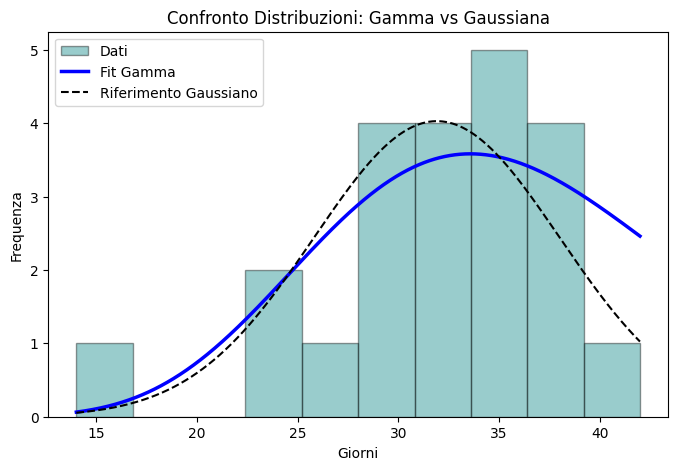

In [86]:
# 1. Preparazione variabili e istogramma
M = ceil(max(days_passed))
m = floor(min(days_passed))
MU = np.mean(days_passed)
DEV = np.std(days_passed)

N_bins = 10
x_range = (m, M)
bin_content, bin_edges = np.histogram(days_passed, bins=N_bins, range=x_range)
N_events = sum(bin_content)
bin_width = bin_edges[1] - bin_edges[0]

# 2. Definizione della funzione Gamma binnata (usando la CDF)
def gamma_binned(x, N_signal, a, loc, scale):
    return N_signal * gamma.cdf(x, a, loc, scale)

# 3. Inizializzazione parametri per la Gamma
# La Gamma ha 3 parametri: 
# a (shape), loc (spostamento/offset), scale (fattore di scala)
initial_scale = DEV**2 / MU   # Stima statistica iniziale
initial_a = MU / initial_scale

# 1. Calcoli più solidi per i punti di partenza
# Per una Gamma, la media è a*scale + loc
# Fissiamo loc = 0 per stabilità
fixed_loc = 0 
stima_scale = DEV**2 / MU
stima_a = MU / stima_scale

# 2. Configurazione del Fit
cost_func_gamma = ExtendedBinnedNLL(bin_content, bin_edges, gamma_binned)
my_minuit = Minuit(cost_func_gamma, 
                    N_signal = N_events, 
                    a = stima_a, 
                    loc = fixed_loc, 
                    scale = stima_scale)

# 3. ISTRUZIONI CRITICHE PER MINUIT:
my_minuit.fixed["loc"] = True # Blocca il loc a 0, non farlo muovere!
my_minuit.limits["scale"] = (0.5, 10) # Impedisci alla curva di diventare una "lama"
my_minuit.limits["a"] = (1, 100)      # Impedisci valori di forma assurdi

my_minuit.migrad()

# 5. Output dei risultati
print(f"Fit Valido: {my_minuit.valid}")
for par, val, err in zip(my_minuit.parameters, my_minuit.values, my_minuit.errors):
    print(f'{par} = {val:.3f} +/- {err:.3f}')

# 6. Estrazione valori per il grafico
N_g, a_g, loc_g, scale_g = my_minuit.values

# 7. Creazione curve per il confronto
x_plot = np.linspace(m, M, 1000)
# Curva Gamma
y_gamma = N_g * bin_width * gamma.pdf(x_plot, a_g, loc_g, scale_g)
# Curva Gaussiana (usando i valori MU e DEV originali per confronto visivo)
y_gauss = N_events * bin_width * norm.pdf(x_plot, MU, DEV)

# 8. Disegno del grafico
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(days_passed, bins=bin_edges, range=(m, M), color='teal', 
        edgecolor='black', alpha=0.4, label='Dati')

ax.plot(x_plot, y_gamma, color='blue', lw=2.5, label='Fit Gamma')
ax.plot(x_plot, y_gauss, color='black', linestyle='--', lw=1.5, label='Riferimento Gaussiano')

ax.set_title("Confronto Distribuzioni: Gamma vs Gaussiana")
ax.set_xlabel("Giorni")
ax.set_ylabel("Frequenza")
ax.legend()
plt.show()

In [72]:
# Calcolo l'intervallo 95% con la Gamma
inf = gamma.ppf(0.025, a_g, loc_g, scale_g)
sup = gamma.ppf(0.975, a_g, loc_g, scale_g)
print(f"Il prossimo ciclo sarà tra {inf:.1f} e {sup:.1f} giorni (Prob 95%)")

Il prossimo ciclo sarà tra 20.1 e 56.5 giorni (Prob 95%)


In [74]:
giorno_x = 30
prob_iniziato = gamma.cdf(giorno_x, a_g, loc_g, scale_g)
print(f"Probabilità che inizi entro il giorno {giorno_x}: {prob_iniziato*100:.1f}%")

Probabilità che inizi entro il giorno 30: 27.6%


In [ ]:
# --- GAUSSIAN FIT ---
# Captures the "average" behavior assuming symmetry
cost_gauss = ExtendedBinnedNLL(bin_content, bin_edges, func.gauss_binned)
res_gauss = Minuit(cost_gauss, N_signal=N_events, mu=MU, sigma=DEV)
res_gauss.migrad()

# --- GAMMA FIT ---
# Captures the asymmetry and the "14-day" outlier risk
cost_gamma = ExtendedBinnedNLL(bin_content, bin_edges, gamma_binned)
# We fix loc=0 to ensure the distribution starts from a physical origin
res_gamma = Minuit(cost_gamma, N_signal=N_events, a=initial_a, loc=0, scale=initial_scale)
res_gamma.fixed["loc"] = True 
res_gamma.limits["scale"] = (0.5, 10) # Prevents the "spike" error
res_gamma.migrad()

# --- MODEL COMPARISON (AIC) ---
# Lower AIC means a better balance between fit quality and complexity
aic_gauss = 2*3 + res_gauss.fval
aic_gamma = 2*3 + res_gamma.fval

print(f"AIC Gaussian: {aic_gauss:.2f}")
print(f"AIC Gamma:    {aic_gamma:.2f}")

# --- ENSEMBLE PREDICTION FUNCTION ---
def future_prediction(target_day):
    """
    Combines both models to calculate the probability 
    that the cycle will have started by a specific day.
    """
    # Gaussian Probability (Cumulative Distribution Function)
    p_gauss = norm.cdf(target_day, res_gauss.values['mu'], res_gauss.values['sigma'])
    
    # Gamma Probability (Cumulative Distribution Function)
    p_gamma = gamma.cdf(target_day, res_gamma.values['a'], 
                        res_gamma.values['loc'], res_gamma.values['scale'])
    
    # Ensemble average
    avg_prob = (p_gauss + p_gamma) / 2
    return avg_prob

# --- TEST THE PREDICTION ---
# Example: What is the probability that the cycle starts by day 35?
day_to_check = 35
result = future_prediction(day_to_check)

print("-" * 30)
print(f"Combined Prediction for day {day_to_check}: {result*100:.1f}% probability")

AIC Gaussian: 13.36
AIC Gamma:    14.70
------------------------------
Combined Prediction for day 35: 54.5% probability


In [87]:
day = 30
future_prediction(day)
print(f"Prediction for day {day}: {result*100:.1f}% probability")

Prediction for day 30: 54.5% probability


In [92]:

def probabilità_inizio_oggi_date(g_u, m_u, g_o, m_o, res_gauss, res_gamma):
    """
    Calculates the probability of the cycle starting today based on calendar dates.
    
    Inputs:
        g_u, m_u: Day and month of the last cycle start.
        g_o, m_o: Day and month of today.
    """
    anno_corrente = date.today().year
    
    # 1. Create date objects
    data_ultimo = date(anno_corrente, m_u, g_u)
    data_oggi = date(anno_corrente, m_o, g_o)
    
    # 2. Handle year crossover (if today is 'earlier' in the calendar than the last cycle)
    if data_oggi < data_ultimo:
        # This implies the last cycle was in the previous year
        data_ultimo = date(anno_corrente - 1, m_u, g_u)
    
    # 3. Calculate the difference in days
    delta = (data_oggi - data_ultimo).days
    
    # Define the 24-hour window for "today"
    d_start = delta
    d_end = delta + 1
    
    # 4. Gaussian Probability (CDF difference)
    p_gauss = (norm.cdf(d_end, res_gauss.values['mu'], res_gauss.values['sigma']) - 
               norm.cdf(d_start, res_gauss.values['mu'], res_gauss.values['sigma']))
    
    # 5. Gamma Probability (CDF difference)
    p_gamma = (gamma.cdf(d_end, res_gamma.values['a'], 
                         res_gamma.values['loc'], res_gamma.values['scale']) - 
               gamma.cdf(d_start, res_gamma.values['a'], 
                         res_gamma.values['loc'], res_gamma.values['scale']))
    
    # 6. Ensemble Average
    final_prob = (p_gauss + p_gamma) / 2
    
    return delta, final_prob

# --- EXAMPLE USAGE ---
# Last cycle: Feb 21st | Today: March 15th
days, prob = probabilità_inizio_oggi_date(21, 2, 15, 3, res_gauss, res_gamma)

print(f"Days since last cycle: {days}")
print(f"Probability of starting today: {prob*100:.2f}%")

Days since last cycle: 22
Probability of starting today: 1.68%


In [98]:
# --- EXAMPLE USAGE ---
# Last cycle: Feb 21st | Today: March 15th
days, prob = probabilità_inizio_oggi_date(17, 3, 19, 4, res_gauss, res_gamma)

print(f"Days since last cycle: {days}")
print(f"Probability of starting today: {prob*100:.2f}%")

Days since last cycle: 33
Probability of starting today: 5.09%


In [99]:
def probabilità_entro_oggi(g_u, m_u, g_o, m_o, res_gauss, res_gamma):
    # 1. Calcolo dei giorni trascorsi (logica datetime)
    data_ultimo = date(date.today().year, m_u, g_u)
    data_oggi = date(date.today().year, m_o, g_o)
    if data_oggi < data_ultimo:
        data_ultimo = date(date.today().year - 1, m_u, g_u)
    
    delta = (data_oggi - data_ultimo).days
    giorno_target = delta + 1 # Calcoliamo la probabilità fino alla FINE di oggi
    
    # 2. Probabilità cumulata Gaussiana
    # Usiamo i nomi dei parametri estratti dal tuo fit res_gauss
    p_gauss = norm.cdf(giorno_target, 
                       res_gauss.values['mu'], 
                       res_gauss.values['sigma'])
    
    # 3. Probabilità cumulata Gamma
    # Usiamo i nomi dei parametri estratti dal tuo fit res_gamma
    p_gamma = gamma.cdf(giorno_target, 
                        res_gamma.values['a'], 
                        res_gamma.values['loc'], 
                        res_gamma.values['scale'])
    
    # 4. Media Ensemble (il nostro "responso" finale)
    prob_entro_oggi = (p_gauss + p_gamma) / 2
    
    return delta, prob_entro_oggi

In [107]:
mese_ultimo_ciclo = 3
giorno_ultimo_ciclo = 17
mese_corrente = 4
giorno_corrente = 15

giorni, prob = probabilità_entro_oggi(giorno_ultimo_ciclo, mese_ultimo_ciclo, giorno_corrente, mese_corrente, res_gauss, res_gamma)

print(f"Oggi è il:",giorno_corrente,"/",mese_corrente)
print(f"l'ultimo ciclo è stato il:",giorno_ultimo_ciclo,"/",mese_ultimo_ciclo)

print(f"Giorni dall'ultimo ciclo: {giorni}")
print(f"Probabilità che il ciclo inizi oggi: {prob*100:.2f}%")

Oggi è il: 15 / 4
l'ultimo ciclo è stato il: 17 / 3
Giorni dall'ultimo ciclo: 29
Probabilità che il ciclo inizi oggi: 29.65%
